# Dataset & LIbraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os

import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers, Sequential

import matplotlib.pyplot as plt
import numpy as np
#from sklearn.utils import 
from sklearn.metrics import confusion_matrix, classification_report

In [21]:
source_dir = "/kaggle/input/datasets/geadalfa/cracked-non-cracked-surface-datasets/Bangunan Retak"
dest_dir = "/kaggle/working/NewDataset"

Splitting into separate Train, Val & Test folders

In [ ]:
import splitfolders
splitfolders.ratio(source_dir, output=dest_dir, ratio=(.8, .15, .05), group_prefix=None, move=False)

# Preprocessing

Image Dataset Preprocessing and Loading

In [24]:
batch_size = 64
image_size = (224, 224)

train = keras.preprocessing.image_dataset_from_directory(dest_dir + '/train', label_mode = "categorical", batch_size = batch_size, image_size = image_size, )
val = keras.preprocessing.image_dataset_from_directory(dest_dir + '/val', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )
test = keras.preprocessing.image_dataset_from_directory(dest_dir + '/test', label_mode = "categorical", batch_size = batch_size, image_size = image_size, shuffle = False, )

Found 76873 files belonging to 2 classes.
Found 14413 files belonging to 2 classes.
Found 4806 files belonging to 2 classes.


Performance Optimization: Prefetch

In [25]:
train_copy = train
test_copy = test
train = train.prefetch(buffer_size=tf.data.AUTOTUNE)
val = val.prefetch(buffer_size=tf.data.AUTOTUNE)
test = test.prefetch(buffer_size=tf.data.AUTOTUNE)

Class Weight Computation for Imbalanced Datasets

In [26]:
import os
import numpy as np
from sklearn.utils import class_weight

# 1. Define the path to your training folder 
# (This should match what you used in image_dataset_from_directory)
train_dir = dest_dir + '/train'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(train_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_train_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(train_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_train_simulated.extend([i] * num_images)

y_train_simulated = np.array(y_train_simulated)

# 4. Compute the class weights using sklearn
class_labels = np.unique(y_train_simulated)
class_weights_array = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=class_labels,
    y=y_train_simulated
)

# 5. Format into the dictionary Keras expects
class_weights = dict(zip(class_labels, class_weights_array))

# Display the results
class_indices = {class_names[i]: i for i in range(len(class_names))}
print(f"Class indices: {class_indices}")
print(f"Calculated weights: {class_weights}")

Class indices: {'Cracked': 0, 'Non Cracked': 1}
Calculated weights: {np.int64(0): np.float64(1.6867731601351648), np.int64(1): np.float64(0.7106552527456274)}


# Hyperparameter optimization

In [27]:
!pip install optuna
!pip install optuna-integration[tfkeras]

Hyperparameter Tuning for Bidirectional LSTM Image Column Scanning

In [28]:
import optuna
from optuna.integration import TFKerasPruningCallback
from keras import layers, regularizers

# Take 200 batches for training and 50 batches for validation.
tune_train = train.take(200)

def objective(trial):
    # 1. Clear session to avoid cluttering GPU memory
    tf.keras.backend.clear_session()
    
    # --- 2. Suggest Hyperparameters ---
    lstm_units = trial.suggest_categorical("lstm_units", [32, 64, 128])
    dense_units = trial.suggest_int("dense_units", 128, 512, step=128)
    dropout_rate = trial.suggest_float("dropout_rate", 0.2, 0.5)
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    
    # --- 3. Build Column-by-Column RNN Model ---
    inputs = tf.keras.layers.Input(shape=(224, 224, 3))
    
    # Downsample to 56x56
    x = layers.AveragePooling2D((4, 4))(inputs)
    
    # === COLUMN BY COLUMN SCANNER ONLY ===
    # Original shape: (batch_size, height=56, width=56, channels=3)
    
    # 1. Swap axes so 'width' becomes the time steps sequence
    # Shape becomes: (batch_size, width=56, height=56, channels=3)
    x_cols = layers.Permute((2, 1, 3))(x)
    
    # 2. Flatten the height and channels into a single 1D vector per time step
    # Shape becomes: (batch_size, 56 time_steps, 168 features)
    x_cols = layers.Reshape((56, 56 * 3))(x_cols)
    
    # 3. Process the columns sequentially (Left-to-Right & Right-to-Left)
    rnn_output = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=False)
    )(x_cols)
    
    # === Classification Head ===
    x_head = layers.BatchNormalization()(rnn_output)
    x_head = layers.Dense(dense_units, activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x_head)
    x_head = layers.Dropout(dropout_rate)(x_head)
    outputs = layers.Dense(2, activation="softmax")(x_head)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # --- 4. Compile Model ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    # --- 5. Callbacks & Training ---
    callbacks = [
        TFKerasPruningCallback(trial, monitor="val_accuracy"),
        tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)
    ]
    
    history = model.fit(
        tune_train, 
        validation_data=val,
        epochs=15,       
        callbacks=callbacks,
        class_weight=class_weights,
    )
    
    return max(history.history["val_accuracy"])

# Run the study
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20) 

print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

[I 2026-05-08 12:37:30,964] A new study created in memory with name: no-name-5cf60d3c-a9c3-4c00-95cc-706efad2154f


Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6803 - loss: 0.6523 - val_accuracy: 0.2976 - val_loss: 0.7732
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.5066 - loss: 0.6981 - val_accuracy: 0.7035 - val_loss: 0.6187
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.4639 - loss: 0.6983 - val_accuracy: 0.2990 - val_loss: 0.6980
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.4906 - loss: 0.6965 - val_accuracy: 0.2987 - val_loss: 1.1393
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.4559 - loss: 0.6959 - val_accuracy: 0.2977 - val_loss: 1.0366


[I 2026-05-08 12:38:33,328] Trial 0 finished with value: 0.7035315632820129 and parameters: {'lstm_units': 128, 'dense_units': 512, 'dropout_rate': 0.23062753225000512, 'lr': 0.0009372888908086764}. Best is trial 0 with value: 0.7035315632820129.


Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.7293 - loss: 0.6167 - val_accuracy: 0.2992 - val_loss: 0.7652
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 16s 80ms/step - accuracy: 0.7850 - loss: 0.5254 - val_accuracy: 0.8102 - val_loss: 0.6420
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7941 - loss: 0.5229 - val_accuracy: 0.6559 - val_loss: 0.6928
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7994 - loss: 0.5221 - val_accuracy: 0.8055 - val_loss: 0.6374
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.7990 - loss: 0.5113 - val_accuracy: 0.2970 - val_loss: 1.2381


[I 2026-05-08 12:39:39,869] Trial 1 finished with value: 0.810171365737915 and parameters: {'lstm_units': 64, 'dense_units': 384, 'dropout_rate': 0.36359662949155724, 'lr': 0.0002507499356392035}. Best is trial 1 with value: 0.810171365737915.


...

Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7363 - loss: 0.6040

[I 2026-05-08 12:53:32,088] Trial 18 pruned. Trial was pruned at epoch 0.


Epoch 1/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - accuracy: 0.6495 - loss: 0.6142 - val_accuracy: 0.8005 - val_loss: 0.5040
Epoch 2/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7794 - loss: 0.5276 - val_accuracy: 0.8056 - val_loss: 0.5115
Epoch 3/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.7981 - loss: 0.5025 - val_accuracy: 0.7914 - val_loss: 0.5074
Epoch 4/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8062 - loss: 0.4891 - val_accuracy: 0.7969 - val_loss: 0.5079
Epoch 5/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 59ms/step - accuracy: 0.8091 - loss: 0.4840 - val_accuracy: 0.8182 - val_loss: 0.4668
Epoch 6/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8117 - loss: 0.4752 - val_accuracy: 0.7952 - val_loss: 0.4965
Epoch 7/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8154 - loss: 0.4709 - val_accuracy: 0.8372 - val_loss: 0.4287
Epoch 8/15
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8137 - loss: 0.4691 - 

[I 2026-05-08 12:55:32,361] Trial 19 finished with value: 0.8371608853340149 and parameters: {'lstm_units': 64, 'dense_units': 512, 'dropout_rate': 0.46222508539630214, 'lr': 4.5362413770600536e-05}. Best is trial 4 with value: 0.849857747554779.


Best trial: 0.849857747554779
Best params: {'lstm_units': 128, 'dense_units': 384, 'dropout_rate': 0.48522714924605626, 'lr': 0.00013317879070097664}


In [29]:
print(f"Best trial: {study.best_trial.value}")
print(f"Best params: {study.best_trial.params}")

Best trial: 0.849857747554779
Best params: {'lstm_units': 128, 'dense_units': 384, 'dropout_rate': 0.48522714924605626, 'lr': 0.00013317879070097664}


# Training

Reconstructing and Training the Final Model with Optimal Hyperparameters

In [30]:
# --- 1. Parse the Best Parameters Automatically ---
best_params = study.best_params
print("Training final model with parameters:", best_params)

# --- 2. Re-instantiate Data Augmentation ---
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
], name="data_augmentation")

# --- 3. Build Final Model Dynamically using Parsed Variables ---
inputs = tf.keras.layers.Input(shape=(224, 224, 3))

# Connect data augmentation to the inputs
x = data_augmentation(inputs)

# Downsample to 56x56 
x = layers.AveragePooling2D((4, 4))(x)

# === COLUMN BY COLUMN SCANNER ONLY ===
# Transpose image to scan across the width
x_cols = layers.Permute((2, 1, 3))(x)
x_cols = layers.Reshape((56, 56 * 3))(x_cols)

# Inject parsed 'lstm_units'
rnn_output = layers.Bidirectional(
    layers.LSTM(best_params['lstm_units'], return_sequences=False)
)(x_cols)

# === Classification Head ===
x_head = layers.BatchNormalization()(rnn_output)

# Inject parsed 'dense_units' and 'dropout_rate'
x_head = layers.Dense(best_params['dense_units'], activation="relu", kernel_regularizer=regularizers.l2(1e-5))(x_head)
x_head = layers.Dropout(best_params['dropout_rate'])(x_head)
outputs = layers.Dense(2, activation="softmax")(x_head)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

# --- 4. Compile using the parsed 'lr' ---
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['lr']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --- 5. Final Callbacks ---
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_crack_model.keras", save_best_only=True, monitor="val_accuracy", mode="max"),
    tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=6, restore_best_weights=True, mode="max"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1, mode="min")
]

# --- 6. Train on the FULL Dataset ---
history = model.fit(
    train,               
    validation_data=val,
    epochs=100,           
    callbacks=callbacks,
    class_weight=class_weights
)

Training final model with parameters: {'lstm_units': 128, 'dense_units': 384, 'dropout_rate': 0.48522714924605626, 'lr': 0.00013317879070097664}
Epoch 1/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 44s 34ms/step - accuracy: 0.7610 - loss: 0.5297 - val_accuracy: 0.3314 - val_loss: 1.7902 - learning_rate: 1.3318e-04
Epoch 2/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.8400 - loss: 0.4323 - val_accuracy: 0.3227 - val_loss: 2.0343 - learning_rate: 1.3318e-04
Epoch 3/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.8476 - loss: 0.4154 - val_accuracy: 0.8649 - val_loss: 0.3760 - learning_rate: 1.3318e-04
Epoch 4/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - accuracy: 0.8543 - loss: 0.4031 - val_accuracy: 0.8741 - val_loss: 0.3648 - learning_rate: 1.3318e-04
Epoch 5/100
1202/1202 ━━━━━━━━━━━━━━━━━━━━ 40s 33ms/step - accuracy: 0.8575 - loss: 0.3955 - val_accuracy: 0.5668 - val_loss: 0.6476 - learning_rate: 1.3318e-04
Epoch 6/100
1201/1202 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms

# Evaluation & Visualization

Model Performance Evaluation on Test Dataset

In [31]:
#loss, accuracy, precision, recall
print(model.evaluate(test))

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.8377 - loss: 0.3160
[0.3347878158092499, 0.882438600063324]


Visualizing Training History: Loss and Accuracy Curves

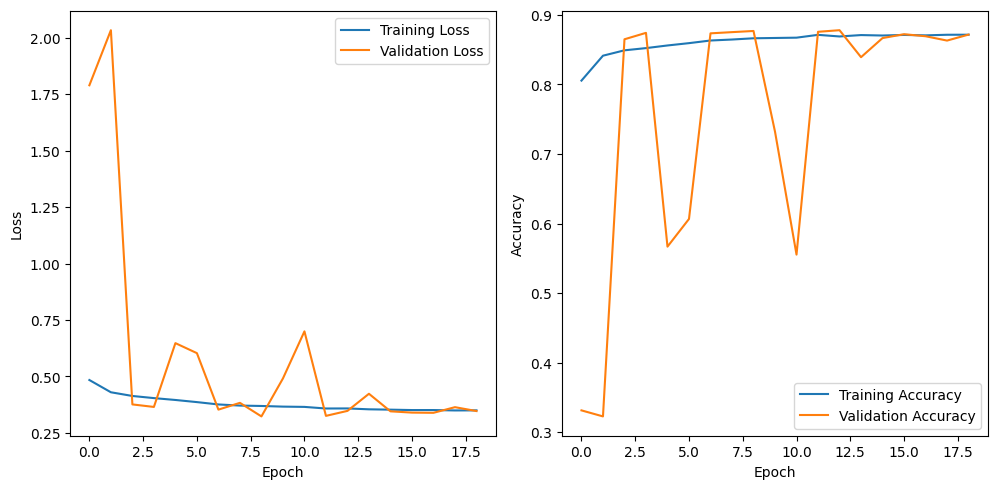

In [32]:
plt.figure(figsize=(15, 5))

# --- Loss ---
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# --- Accuracy ---
plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Confusion Matrix Visualization and Error Analysis

In [33]:
test_dir = dest_dir + '/test'

# 2. Get class names by reading the subfolders 
# (Keras sorts these alphanumerically by default, so we use sorted() to match)
class_names = sorted(os.listdir(test_dir))

# 3. Instantly count the files to build a "dummy" label array
# This takes less than a second, compared to 30 mins with tf.data
y_test_simulated = []
for i, class_name in enumerate(class_names):
    class_path = os.path.join(test_dir, class_name)
    # Count how many images are in this folder
    num_images = len(os.listdir(class_path))
    # Append the class index (0 or 1) 'num_images' times
    y_test_simulated.extend([i] * num_images)

y_true = np.array(y_test_simulated)



# Use the model to predict the classes
y_pred = np.argmax(model.predict(test), axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step


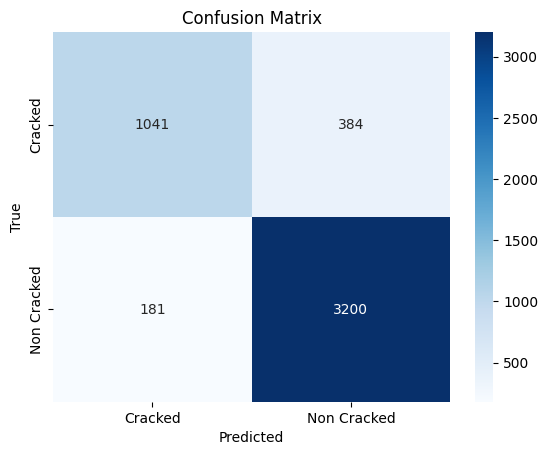

[[1041  384]
 [ 181 3200]]


In [34]:
import seaborn as sns

# Compute and print confusion matrix
conf_matrix = confusion_matrix(y_true, y_pred)

# Visualize confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_copy.class_names, yticklabels=test_copy.class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
print(conf_matrix)

Loading saved model

In [3]:
Model = keras.models.load_model("best_column-by-column_model.keras")
Model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 56, 56, 3)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_1 (Permute)             │ (None, 56, 56, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 56, 168)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       304,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 384)            │        98,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 384)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,212,808 (4.63 MB)

 Trainable params: 404,098 (1.54 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 808,198 (3.08 MB)